In [30]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

Solving Prince1978A by using GLEE-A9


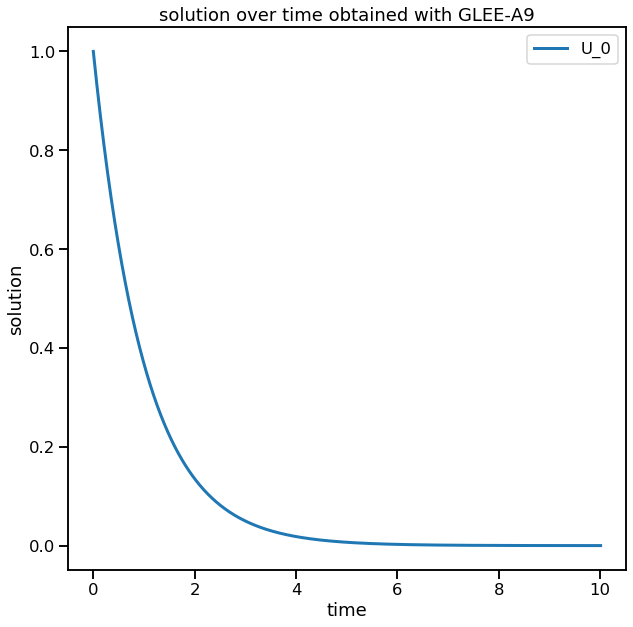

In [31]:
solver=DESolver()
solver.set_info(0)
rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('Prince 1978 A')
solver.setup()
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('GLEE-A9')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u,glee,_,_=solver.get_trajectory_GLEE()


fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.plot(t,u[i,:],'-', lw=3, label = 'U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution over time obtained with {:}'.format(solver.get_method_name()))
plt.show()